# Limpieza y creación del dataset modelable

Este notebook prepara los datos para el modelo de sensor virtual.

El objetivo es seleccionar las variables útiles de los 7 CSV válidos, unificarlas por la columna temporal `Time`, guardar un dataset maestro a 1 segundo y crear un dataset modelable a 10 segundos.


In [2]:
# Importamos librerías principales

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cargamos los 7 CSV válidos del proyecto

nivel_vb01 = pd.read_csv("../data/original/Nivel_VB-01.csv", encoding="utf-16", sep=";", decimal=",")
den_int_vb01 = pd.read_csv("../data/original/Den-Int_VB-01.csv", encoding="utf-16", sep=";", decimal=",")
vapor_he01 = pd.read_csv("../data/original/Vapor_HE-01.csv", encoding="utf-16", sep=";", decimal=",")
vacio = pd.read_csv("../data/original/Vacío.csv", encoding="utf-16", sep=";", decimal=",")
temp_salmuera_he01 = pd.read_csv("../data/original/Temperatura_salmuera_HE01.csv", encoding="utf-16", sep=";", decimal=",")
nivel_caudal_pct02 = pd.read_csv("../data/original/Nivel_Caudal_PCT-02.csv", encoding="utf-16", sep=";", decimal=",")
presion_vb01_he01 = pd.read_csv("../data/original/Presion_VB01_HE01.csv", encoding="utf-16", sep=";", decimal=",")

In [4]:
# Función para preparar cada CSV antes de unirlo por Time

def preparar_time(df, columna_time, prefijo):
    df_tmp = df.copy()
    
    df_tmp = df_tmp.rename(columns={columna_time: "Time"})
    
    df_tmp["Time"] = pd.to_datetime(df_tmp["Time"], dayfirst=True)
    
    columnas_renombradas = {}
    
    for columna in df_tmp.columns:
        if columna != "Time":
            columnas_renombradas[columna] = prefijo + columna
    
    df_tmp = df_tmp.rename(columns=columnas_renombradas)
    
    return df_tmp



In [5]:
# Preparamos los 7 CSV para poder unirlos por Time

nivel_merge = preparar_time(
    nivel_vb01,
    "Valor proceso LT411 Time",
    "nivel_"
)

den_int_merge = preparar_time(
    den_int_vb01,
    "Valor densidad DT412 Time",
    "den_int_"
)

vapor_merge = preparar_time(
    vapor_he01,
    "Caudal vapor FQC-400-1 Time",
    "vapor_"
)

vacio_merge = preparar_time(
    vacio,
    "Valor proceso PT442 Time",
    "vacio_"
)

temp_merge = preparar_time(
    temp_salmuera_he01,
    "Temp TT413 Time",
    "temp_"
)

pct02_merge = preparar_time(
    nivel_caudal_pct02,
    "Valor proceso LT426 Time",
    "pct02_"
)

presion_merge = preparar_time(
    presion_vb01_he01,
    "Valor proceso PIT-410 Time",
    "presion_"
)

## Unión de señales

Una vez normalizados los 7 datasets, se unifican mediante `Time`.

Se utiliza `inner merge` para conservar únicamente los timestamps presentes en todas las señales principales.

In [6]:
# Unimos todos los CSV por la columna Time

dataset_limpio = nivel_merge.merge(den_int_merge, on="Time", how="inner")

dataset_limpio = dataset_limpio.merge(vapor_merge, on="Time", how="inner")
dataset_limpio = dataset_limpio.merge(vacio_merge, on="Time", how="inner")
dataset_limpio = dataset_limpio.merge(temp_merge, on="Time", how="inner")
dataset_limpio = dataset_limpio.merge(pct02_merge, on="Time", how="inner")
dataset_limpio = dataset_limpio.merge(presion_merge, on="Time", how="inner")

dataset_limpio.head()

,Time,nivel_Valor proceso LT411 ValueY,nivel_Set point Time,nivel_Set point ValueY,nivel_Accion (valvula) LV411 Time,nivel_Accion (valvula) LV411 ValueY,den_int_Valor densidad DT412 ValueY,den_int_Valor intensidad P-101 Time,den_int_Valor intensidad P-101 ValueY,vapor_Caudal vapor FQC-400-1 ValueY,...,pct02_Valor proceso LT426 ValueY,pct02_Set point Time,pct02_Set point ValueY,pct02_Accion (valvula) Time,pct02_Accion (valvula) ValueY,pct02_Caudal FT428 Time,pct02_Caudal FT428 ValueY,presion_Valor proceso PIT-410 ValueY,presion_Valor proceso PIT-414 Time,presion_Valor proceso PIT-414 ValueY
0,2021-11-05 08:00:00,57.986111,05/11/2021 8:00:00,60,05/11/2021 8:00:00,100.0,1229.817627,05/11/2021 8:00:00,57.118053,3046.870850,...,50.462963,05/11/2021 8:00:00,50,05/11/2021 8:00:00,18.678579,05/11/2021 8:00:00,6.250000,0.326244,05/11/2021 8:00:00,0.579282
1,2021-11-05 08:00:01,58.043980,05/11/2021 8:00:01,60,05/11/2021 8:00:01,100.0,1230.078125,05/11/2021 8:00:01,57.899303,3052.296387,...,50.462963,05/11/2021 8:00:01,50,05/11/2021 8:00:01,18.700279,05/11/2021 8:00:01,6.258681,0.326244,05/11/2021 8:00:01,0.579282
2,2021-11-05 08:00:02,58.130787,05/11/2021 8:00:02,60,05/11/2021 8:00:02,100.0,1230.078125,05/11/2021 8:00:02,59.172451,3053.661865,...,50.462963,05/11/2021 8:00:02,50,05/11/2021 8:00:02,19.011200,05/11/2021 8:00:02,6.267362,0.326244,05/11/2021 8:00:02,0.579282
3,2021-11-05 08:00:03,58.188656,05/11/2021 8:00:03,60,05/11/2021 8:00:03,100.0,1229.947876,05/11/2021 8:00:03,59.056713,3053.177246,...,50.405090,05/11/2021 8:00:03,50,05/11/2021 8:00:03,18.743103,05/11/2021 8:00:03,6.271702,0.325926,05/11/2021 8:00:03,0.579282
4,2021-11-05 08:00:04,58.217590,05/11/2021 8:00:04,60,05/11/2021 8:00:04,100.0,1229.817627,05/11/2021 8:00:04,58.796295,3053.177246,...,50.405090,05/11/2021 8:00:04,50,05/11/2021 8:00:04,18.764515,05/11/2021 8:00:04,6.271702,0.325926,05/11/2021 8:00:04,0.579282


In [7]:
# Revisamos las columnas disponibles después de unir todos los CSV

dataset_limpio.columns.tolist()

['Time',
 'nivel_Valor proceso LT411 ValueY',
 'nivel_Set point Time',
 'nivel_Set point ValueY',
 'nivel_Accion (valvula) LV411 Time',
 'nivel_Accion (valvula) LV411 ValueY',
 'den_int_Valor densidad DT412 ValueY',
 'den_int_Valor intensidad P-101 Time',
 'den_int_Valor intensidad P-101 ValueY',
 'vapor_Caudal vapor FQC-400-1 ValueY',
 'vapor_Set point Time',
 'vapor_Set point ValueY',
 'vapor_Acción válvula FV400-1 Time',
 'vapor_Acción válvula FV400-1 ValueY',
 'vacio_Valor proceso PT442 ValueY',
 'vacio_Set point Time',
 'vacio_Set point ValueY',
 'vacio_Accion (valvula) PV442 Time',
 'vacio_Accion (valvula) PV442 ValueY',
 'temp_Temp TT413 ValueY',
 'temp_Temp TT415 Time',
 'temp_Temp TT415 ValueY',
 'pct02_Valor proceso LT426 ValueY',
 'pct02_Set point Time',
 'pct02_Set point ValueY',
 'pct02_Accion (valvula) Time',
 'pct02_Accion (valvula) ValueY',
 'pct02_Caudal FT428 Time',
 'pct02_Caudal FT428 ValueY',
 'presion_Valor proceso PIT-410 ValueY',
 'presion_Valor proceso PIT-414 

In [8]:
# Seleccionamos solo las columnas útiles para el proyecto

columnas_utiles = [
    "Time",
    
    "nivel_Valor proceso LT411 ValueY",
    "nivel_Set point ValueY",
    "nivel_Accion (valvula) LV411 ValueY",
    
    "den_int_Valor densidad DT412 ValueY",
    "den_int_Valor intensidad P-101 ValueY",
    
    "vapor_Caudal vapor FQC-400-1 ValueY",
    "vapor_Set point ValueY",
    "vapor_Acción válvula FV400-1 ValueY",
    
    "vacio_Valor proceso PT442 ValueY",
    "vacio_Set point ValueY",
    "vacio_Accion (valvula) PV442 ValueY",
    
    "temp_Temp TT413 ValueY",
    "temp_Temp TT415 ValueY",
    
    "pct02_Valor proceso LT426 ValueY",
    "pct02_Set point ValueY",
    "pct02_Accion (valvula) ValueY",
    "pct02_Caudal FT428 ValueY",
    
    "presion_Valor proceso PIT-410 ValueY",
    "presion_Valor proceso PIT-414 ValueY"
]

dataset_limpio = dataset_limpio[columnas_utiles].copy()

dataset_limpio.head()

,Time,nivel_Valor proceso LT411 ValueY,nivel_Set point ValueY,nivel_Accion (valvula) LV411 ValueY,den_int_Valor densidad DT412 ValueY,den_int_Valor intensidad P-101 ValueY,vapor_Caudal vapor FQC-400-1 ValueY,vapor_Set point ValueY,vapor_Acción válvula FV400-1 ValueY,vacio_Valor proceso PT442 ValueY,vacio_Set point ValueY,vacio_Accion (valvula) PV442 ValueY,temp_Temp TT413 ValueY,temp_Temp TT415 ValueY,pct02_Valor proceso LT426 ValueY,pct02_Set point ValueY,pct02_Accion (valvula) ValueY,pct02_Caudal FT428 ValueY,presion_Valor proceso PIT-410 ValueY,presion_Valor proceso PIT-414 ValueY
0,2021-11-05 08:00:00,57.986111,60,100.0,1229.817627,57.118053,3046.870850,69,59.5,0.153935,0.14,0.0,80.989586,81.857643,50.462963,50,18.678579,6.250000,0.326244,0.579282
1,2021-11-05 08:00:01,58.043980,60,100.0,1230.078125,57.899303,3052.296387,69,59.5,0.154514,0.14,0.0,80.989586,81.814240,50.462963,50,18.700279,6.258681,0.326244,0.579282
2,2021-11-05 08:00:02,58.130787,60,100.0,1230.078125,59.172451,3053.661865,69,59.5,0.154514,0.14,0.0,80.989586,81.857643,50.462963,50,19.011200,6.267362,0.326244,0.579282
3,2021-11-05 08:00:03,58.188656,60,100.0,1229.947876,59.056713,3053.177246,69,59.5,0.154514,0.14,0.0,80.946182,81.814240,50.405090,50,18.743103,6.271702,0.325926,0.579282
4,2021-11-05 08:00:04,58.217590,60,100.0,1229.817627,58.796295,3053.177246,69,59.5,0.154514,0.14,0.0,80.946182,81.814240,50.405090,50,18.764515,6.271702,0.325926,0.579282


In [9]:
# Renombramos las columnas finales del dataset

dataset_limpio = dataset_limpio.rename(columns={
    "nivel_Valor proceso LT411 ValueY": "LT411",
    "nivel_Set point ValueY": "SP_LT411",
    "nivel_Accion (valvula) LV411 ValueY": "LV411",
    
    "den_int_Valor densidad DT412 ValueY": "DT412",
    "den_int_Valor intensidad P-101 ValueY": "INT_P101",
    
    "vapor_Caudal vapor FQC-400-1 ValueY": "FQC400_1",
    "vapor_Set point ValueY": "SP_VAPOR",
    "vapor_Acción válvula FV400-1 ValueY": "FV400_1",
    
    "vacio_Valor proceso PT442 ValueY": "PT442",
    "vacio_Set point ValueY": "SP_PT442",
    "vacio_Accion (valvula) PV442 ValueY": "PV442",
    
    "temp_Temp TT413 ValueY": "TT413",
    "temp_Temp TT415 ValueY": "TT415",
    
    "pct02_Valor proceso LT426 ValueY": "LT426",
    "pct02_Set point ValueY": "SP_LT426",
    "pct02_Accion (valvula) ValueY": "ACCION_PCT02",
    "pct02_Caudal FT428 ValueY": "FT428",
    
    "presion_Valor proceso PIT-410 ValueY": "PIT410",
    "presion_Valor proceso PIT-414 ValueY": "PIT414"
})

dataset_limpio.head()

,Time,LT411,SP_LT411,LV411,DT412,INT_P101,FQC400_1,SP_VAPOR,FV400_1,PT442,SP_PT442,PV442,TT413,TT415,LT426,SP_LT426,ACCION_PCT02,FT428,PIT410,PIT414
0,2021-11-05 08:00:00,57.986111,60,100.0,1229.817627,57.118053,3046.870850,69,59.5,0.153935,0.14,0.0,80.989586,81.857643,50.462963,50,18.678579,6.250000,0.326244,0.579282
1,2021-11-05 08:00:01,58.043980,60,100.0,1230.078125,57.899303,3052.296387,69,59.5,0.154514,0.14,0.0,80.989586,81.814240,50.462963,50,18.700279,6.258681,0.326244,0.579282
2,2021-11-05 08:00:02,58.130787,60,100.0,1230.078125,59.172451,3053.661865,69,59.5,0.154514,0.14,0.0,80.989586,81.857643,50.462963,50,19.011200,6.267362,0.326244,0.579282
3,2021-11-05 08:00:03,58.188656,60,100.0,1229.947876,59.056713,3053.177246,69,59.5,0.154514,0.14,0.0,80.946182,81.814240,50.405090,50,18.743103,6.271702,0.325926,0.579282
4,2021-11-05 08:00:04,58.217590,60,100.0,1229.817627,58.796295,3053.177246,69,59.5,0.154514,0.14,0.0,80.946182,81.814240,50.405090,50,18.764515,6.271702,0.325926,0.579282


In [10]:
# Ordenamos el dataset por tiempo

dataset_limpio = dataset_limpio.sort_values("Time").reset_index(drop=True)

dataset_limpio.head()

,Time,LT411,SP_LT411,LV411,DT412,INT_P101,FQC400_1,SP_VAPOR,FV400_1,PT442,SP_PT442,PV442,TT413,TT415,LT426,SP_LT426,ACCION_PCT02,FT428,PIT410,PIT414
0,2021-11-05 08:00:00,57.986111,60,100.0,1229.817627,57.118053,3046.870850,69,59.5,0.153935,0.14,0.0,80.989586,81.857643,50.462963,50,18.678579,6.250000,0.326244,0.579282
1,2021-11-05 08:00:01,58.043980,60,100.0,1230.078125,57.899303,3052.296387,69,59.5,0.154514,0.14,0.0,80.989586,81.814240,50.462963,50,18.700279,6.258681,0.326244,0.579282
2,2021-11-05 08:00:02,58.130787,60,100.0,1230.078125,59.172451,3053.661865,69,59.5,0.154514,0.14,0.0,80.989586,81.857643,50.462963,50,19.011200,6.267362,0.326244,0.579282
3,2021-11-05 08:00:03,58.188656,60,100.0,1229.947876,59.056713,3053.177246,69,59.5,0.154514,0.14,0.0,80.946182,81.814240,50.405090,50,18.743103,6.271702,0.325926,0.579282
4,2021-11-05 08:00:04,58.217590,60,100.0,1229.817627,58.796295,3053.177246,69,59.5,0.154514,0.14,0.0,80.946182,81.814240,50.405090,50,18.764515,6.271702,0.325926,0.579282


In [11]:
# Revisamos la estructura final del dataset limpio

print("Filas y columnas:", dataset_limpio.shape)
print("Inicio:", dataset_limpio["Time"].min())
print("Fin:", dataset_limpio["Time"].max())
print("Duplicados Time:", dataset_limpio["Time"].duplicated().sum())
print("Nulos totales:", dataset_limpio.isnull().sum().sum())

Filas y columnas: (230700, 20)
Inicio: 2021-11-05 08:00:00
Fin: 2021-11-08 00:04:59
Duplicados Time: 0
Nulos totales: 0


In [12]:
# Guardamos el dataset unificado a 1 segundo

dataset_limpio.to_csv(
    "../data/data_limpio/dataset_unificado_1s.csv",
    index=False
)

## Comparación de frecuencias de muestreo

A continuación se comparan varias versiones de la señal LT411 con distintas frecuencias temporales.

El objetivo es comprobar visualmente qué frecuencia conserva mejor la dinámica del nivel sin mantener todo el ruido de la señal original a 1 segundo.

Se comparan señales a 1 segundo, 10 segundos, 30 segundos y 1 minuto para justificar la decisión de crear un dataset modelable a 10 segundos.

In [13]:
# Cargamos el dataset unificado para revisar remuestreos

df_grafico = pd.read_csv("../data/data_limpio/dataset_unificado_1s.csv")

df_grafico["Time"] = pd.to_datetime(df_grafico["Time"])

df_grafico = df_grafico.sort_values("Time")

df_grafico = df_grafico.set_index("Time")

df_grafico.head()

,LT411,SP_LT411,LV411,DT412,INT_P101,FQC400_1,SP_VAPOR,FV400_1,PT442,SP_PT442,PV442,TT413,TT415,LT426,SP_LT426,ACCION_PCT02,FT428,PIT410,PIT414
Time,,,,,,,,,,,,,,,,,,,
2021-11-05 08:00:00,57.986111,60,100.0,1229.817627,57.118053,3046.870850,69,59.5,0.153935,0.14,0.0,80.989586,81.857643,50.462963,50,18.678579,6.250000,0.326244,0.579282
2021-11-05 08:00:01,58.043980,60,100.0,1230.078125,57.899303,3052.296387,69,59.5,0.154514,0.14,0.0,80.989586,81.814240,50.462963,50,18.700279,6.258681,0.326244,0.579282
2021-11-05 08:00:02,58.130787,60,100.0,1230.078125,59.172451,3053.661865,69,59.5,0.154514,0.14,0.0,80.989586,81.857643,50.462963,50,19.011200,6.267362,0.326244,0.579282
2021-11-05 08:00:03,58.188656,60,100.0,1229.947876,59.056713,3053.177246,69,59.5,0.154514,0.14,0.0,80.946182,81.814240,50.405090,50,18.743103,6.271702,0.325926,0.579282
2021-11-05 08:00:04,58.217590,60,100.0,1229.817627,58.796295,3053.177246,69,59.5,0.154514,0.14,0.0,80.946182,81.814240,50.405090,50,18.764515,6.271702,0.325926,0.579282


In [14]:
# Creamos varias versiones remuestreadas de LT411

lt411_10s = df_grafico["LT411"].resample("10s").mean()
lt411_30s = df_grafico["LT411"].resample("30s").mean()
lt411_1min = df_grafico["LT411"].resample("1min").mean()

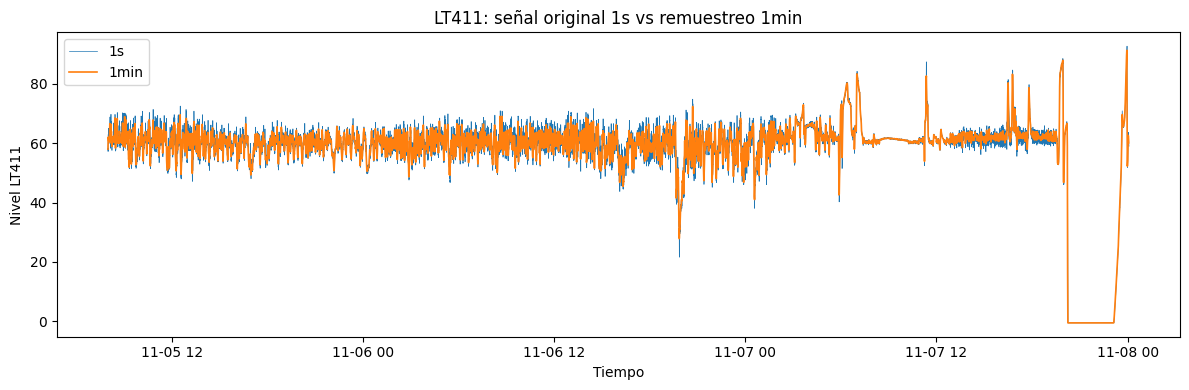

In [15]:
# Gráfico de LT411 original 1s frente a remuestreo 1min

plt.figure(figsize=(12, 4))

plt.plot(df_grafico.index, df_grafico["LT411"], linewidth=0.5, label="1s")
plt.plot(lt411_1min.index, lt411_1min, linewidth=1.2, label="1min")

plt.title("LT411: señal original 1s vs remuestreo 1min")
plt.xlabel("Tiempo")
plt.ylabel("Nivel LT411")
plt.legend()
plt.tight_layout()
plt.show()

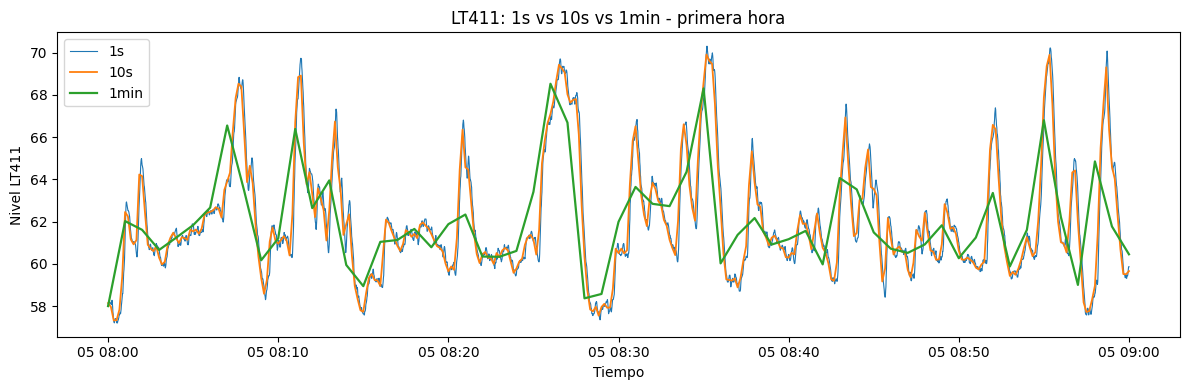

In [16]:
# Gráfico de LT411 durante la primera hora

inicio = df_grafico.index.min()
fin = inicio + pd.Timedelta(hours=1)

plt.figure(figsize=(12, 4))

plt.plot(
    df_grafico.loc[inicio:fin].index,
    df_grafico.loc[inicio:fin, "LT411"],
    linewidth=0.8,
    label="1s"
)

plt.plot(
    lt411_10s.loc[inicio:fin].index,
    lt411_10s.loc[inicio:fin],
    linewidth=1.3,
    label="10s"
)

plt.plot(
    lt411_1min.loc[inicio:fin].index,
    lt411_1min.loc[inicio:fin],
    linewidth=1.6,
    label="1min"
)

plt.title("LT411: 1s vs 10s vs 1min - primera hora")
plt.xlabel("Tiempo")
plt.ylabel("Nivel LT411")
plt.legend()
plt.tight_layout()
plt.show()

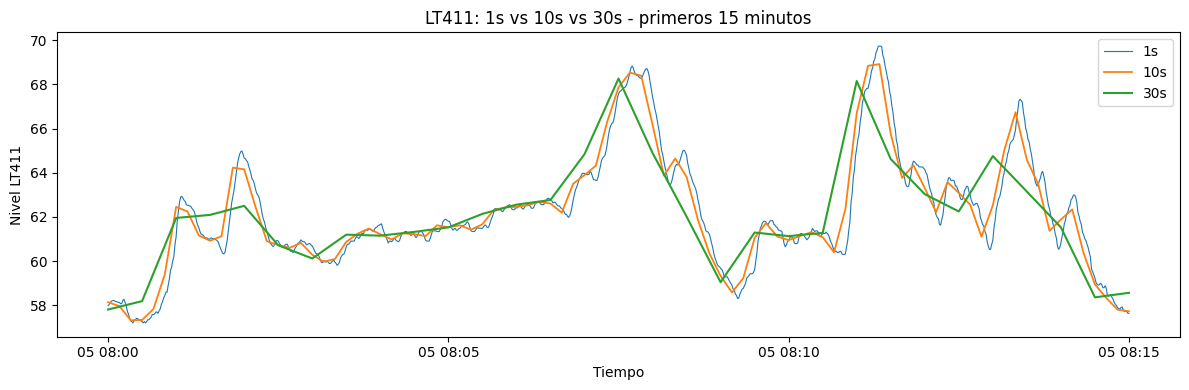

In [17]:
# Gráfico de LT411 durante los primeros 15 minutos

inicio = df_grafico.index.min()
fin = inicio + pd.Timedelta(minutes=15)

plt.figure(figsize=(12, 4))

plt.plot(
    df_grafico.loc[inicio:fin].index,
    df_grafico.loc[inicio:fin, "LT411"],
    linewidth=0.8,
    label="1s"
)

plt.plot(
    lt411_10s.loc[inicio:fin].index,
    lt411_10s.loc[inicio:fin],
    linewidth=1.3,
    label="10s"
)

plt.plot(
    lt411_30s.loc[inicio:fin].index,
    lt411_30s.loc[inicio:fin],
    linewidth=1.5,
    label="30s"
)

plt.title("LT411: 1s vs 10s vs 30s - primeros 15 minutos")
plt.xlabel("Tiempo")
plt.ylabel("Nivel LT411")
plt.legend()
plt.tight_layout()
plt.show()

## Decisión de remuestreo

El remuestreo a 10 segundos mantiene suficientemente la dinámica de `LT411` y reduce el tamaño del dataset.

El remuestreo a 1 minuto suaviza demasiado la señal para el objetivo actual, por lo que se descarta como frecuencia inicial de modelado.

In [18]:
# Creamos el dataset modelable a 10 segundos

df_10s = df_grafico.copy()

df_10s = df_10s.resample("10s").mean(numeric_only=True)

df_10s = df_10s.reset_index()

dataset_modelable = df_10s.copy()

dataset_modelable.head()

,Time,LT411,SP_LT411,LV411,DT412,INT_P101,FQC400_1,SP_VAPOR,FV400_1,PT442,SP_PT442,PV442,TT413,TT415,LT426,SP_LT426,ACCION_PCT02,FT428,PIT410,PIT414
0,2021-11-05 08:00:00,58.142360,60.0,100.0,1229.492151,58.408563,3054.785938,69.0,59.5,0.154167,0.14,0.0,80.976565,81.82292,50.439814,50.0,18.861438,6.266928,0.326085,0.579514
1,2021-11-05 08:00:10,57.962962,60.0,100.0,1229.049451,58.272569,3052.526001,69.0,59.5,0.154282,0.14,0.0,80.954863,81.81424,50.422452,50.0,19.102801,6.293403,0.326181,0.579456
2,2021-11-05 08:00:20,57.323494,60.0,100.0,1229.088501,58.234953,3038.494727,69.0,59.5,0.154225,0.14,0.0,80.946182,81.81424,50.434027,50.0,19.315793,6.325521,0.326403,0.579051
3,2021-11-05 08:00:30,57.335069,60.0,100.0,1228.762976,58.463541,3031.794189,69.0,59.5,0.154282,0.14,0.0,80.946182,81.81424,50.422452,50.0,19.470506,6.357205,0.326340,0.578588
4,2021-11-05 08:00:40,57.835647,60.0,100.0,1229.453088,58.159721,3036.406226,69.0,59.5,0.154485,0.14,0.0,80.946182,81.81424,50.428239,50.0,19.712129,6.391927,0.326403,0.578125


In [19]:
# Revisamos el dataset modelable a 10 segundos

print("Filas y columnas:", dataset_modelable.shape)
print("Inicio:", dataset_modelable["Time"].min())
print("Fin:", dataset_modelable["Time"].max())
print("Duplicados Time:", dataset_modelable["Time"].duplicated().sum())
print("Nulos totales:", dataset_modelable.isnull().sum().sum())

Filas y columnas: (23070, 20)
Inicio: 2021-11-05 08:00:00
Fin: 2021-11-08 00:04:50
Duplicados Time: 0
Nulos totales: 0


In [20]:
# Guardamos el dataset modelable a 10 segundos

dataset_modelable.to_csv(
    "../data/data_limpio/dataset_modelable_10s.csv",
    index=False
)

## Correlaciones entre variables

Una vez creado el dataset unificado y remuestreado a 10 segundos, se revisan correlaciones generales entre variables.

Esta parte es exploratoria. En series temporales industriales la correlación debe interpretarse con cuidado, porque no implica causalidad y puede estar afectada por autocorrelación temporal.

`LV411` se incluye en el análisis visual, pero no se usará como variable del Modelo A por riesgo de contaminación de lazo cerrado.

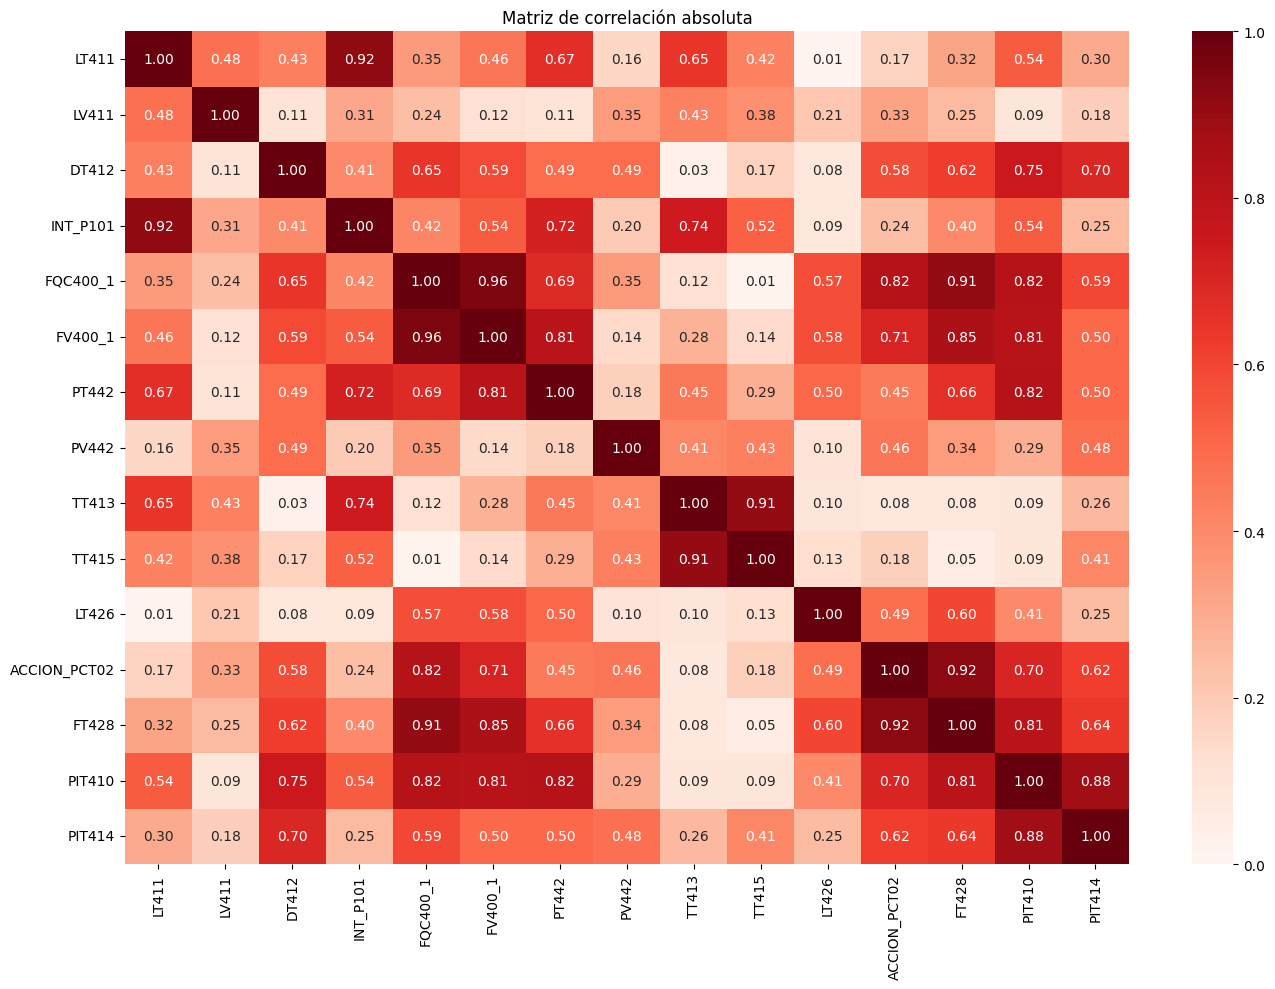

In [21]:
# Heatmap de correlaciones absolutas

variables_heatmap = [
    "LT411",
    "LV411",
    "DT412",
    "INT_P101",
    "FQC400_1",
    "FV400_1",
    "PT442",
    "PV442",
    "TT413",
    "TT415",
    "LT426",
    "ACCION_PCT02",
    "FT428",
    "PIT410",
    "PIT414"
]

df_heatmap = dataset_modelable[variables_heatmap].copy()

matriz_abs = df_heatmap.corr(numeric_only=True).abs()

plt.figure(figsize=(14, 10))

sns.heatmap(
    matriz_abs,
    annot=True,
    vmin=0,
    vmax=1,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Matriz de correlación absoluta")
plt.tight_layout()
plt.show()

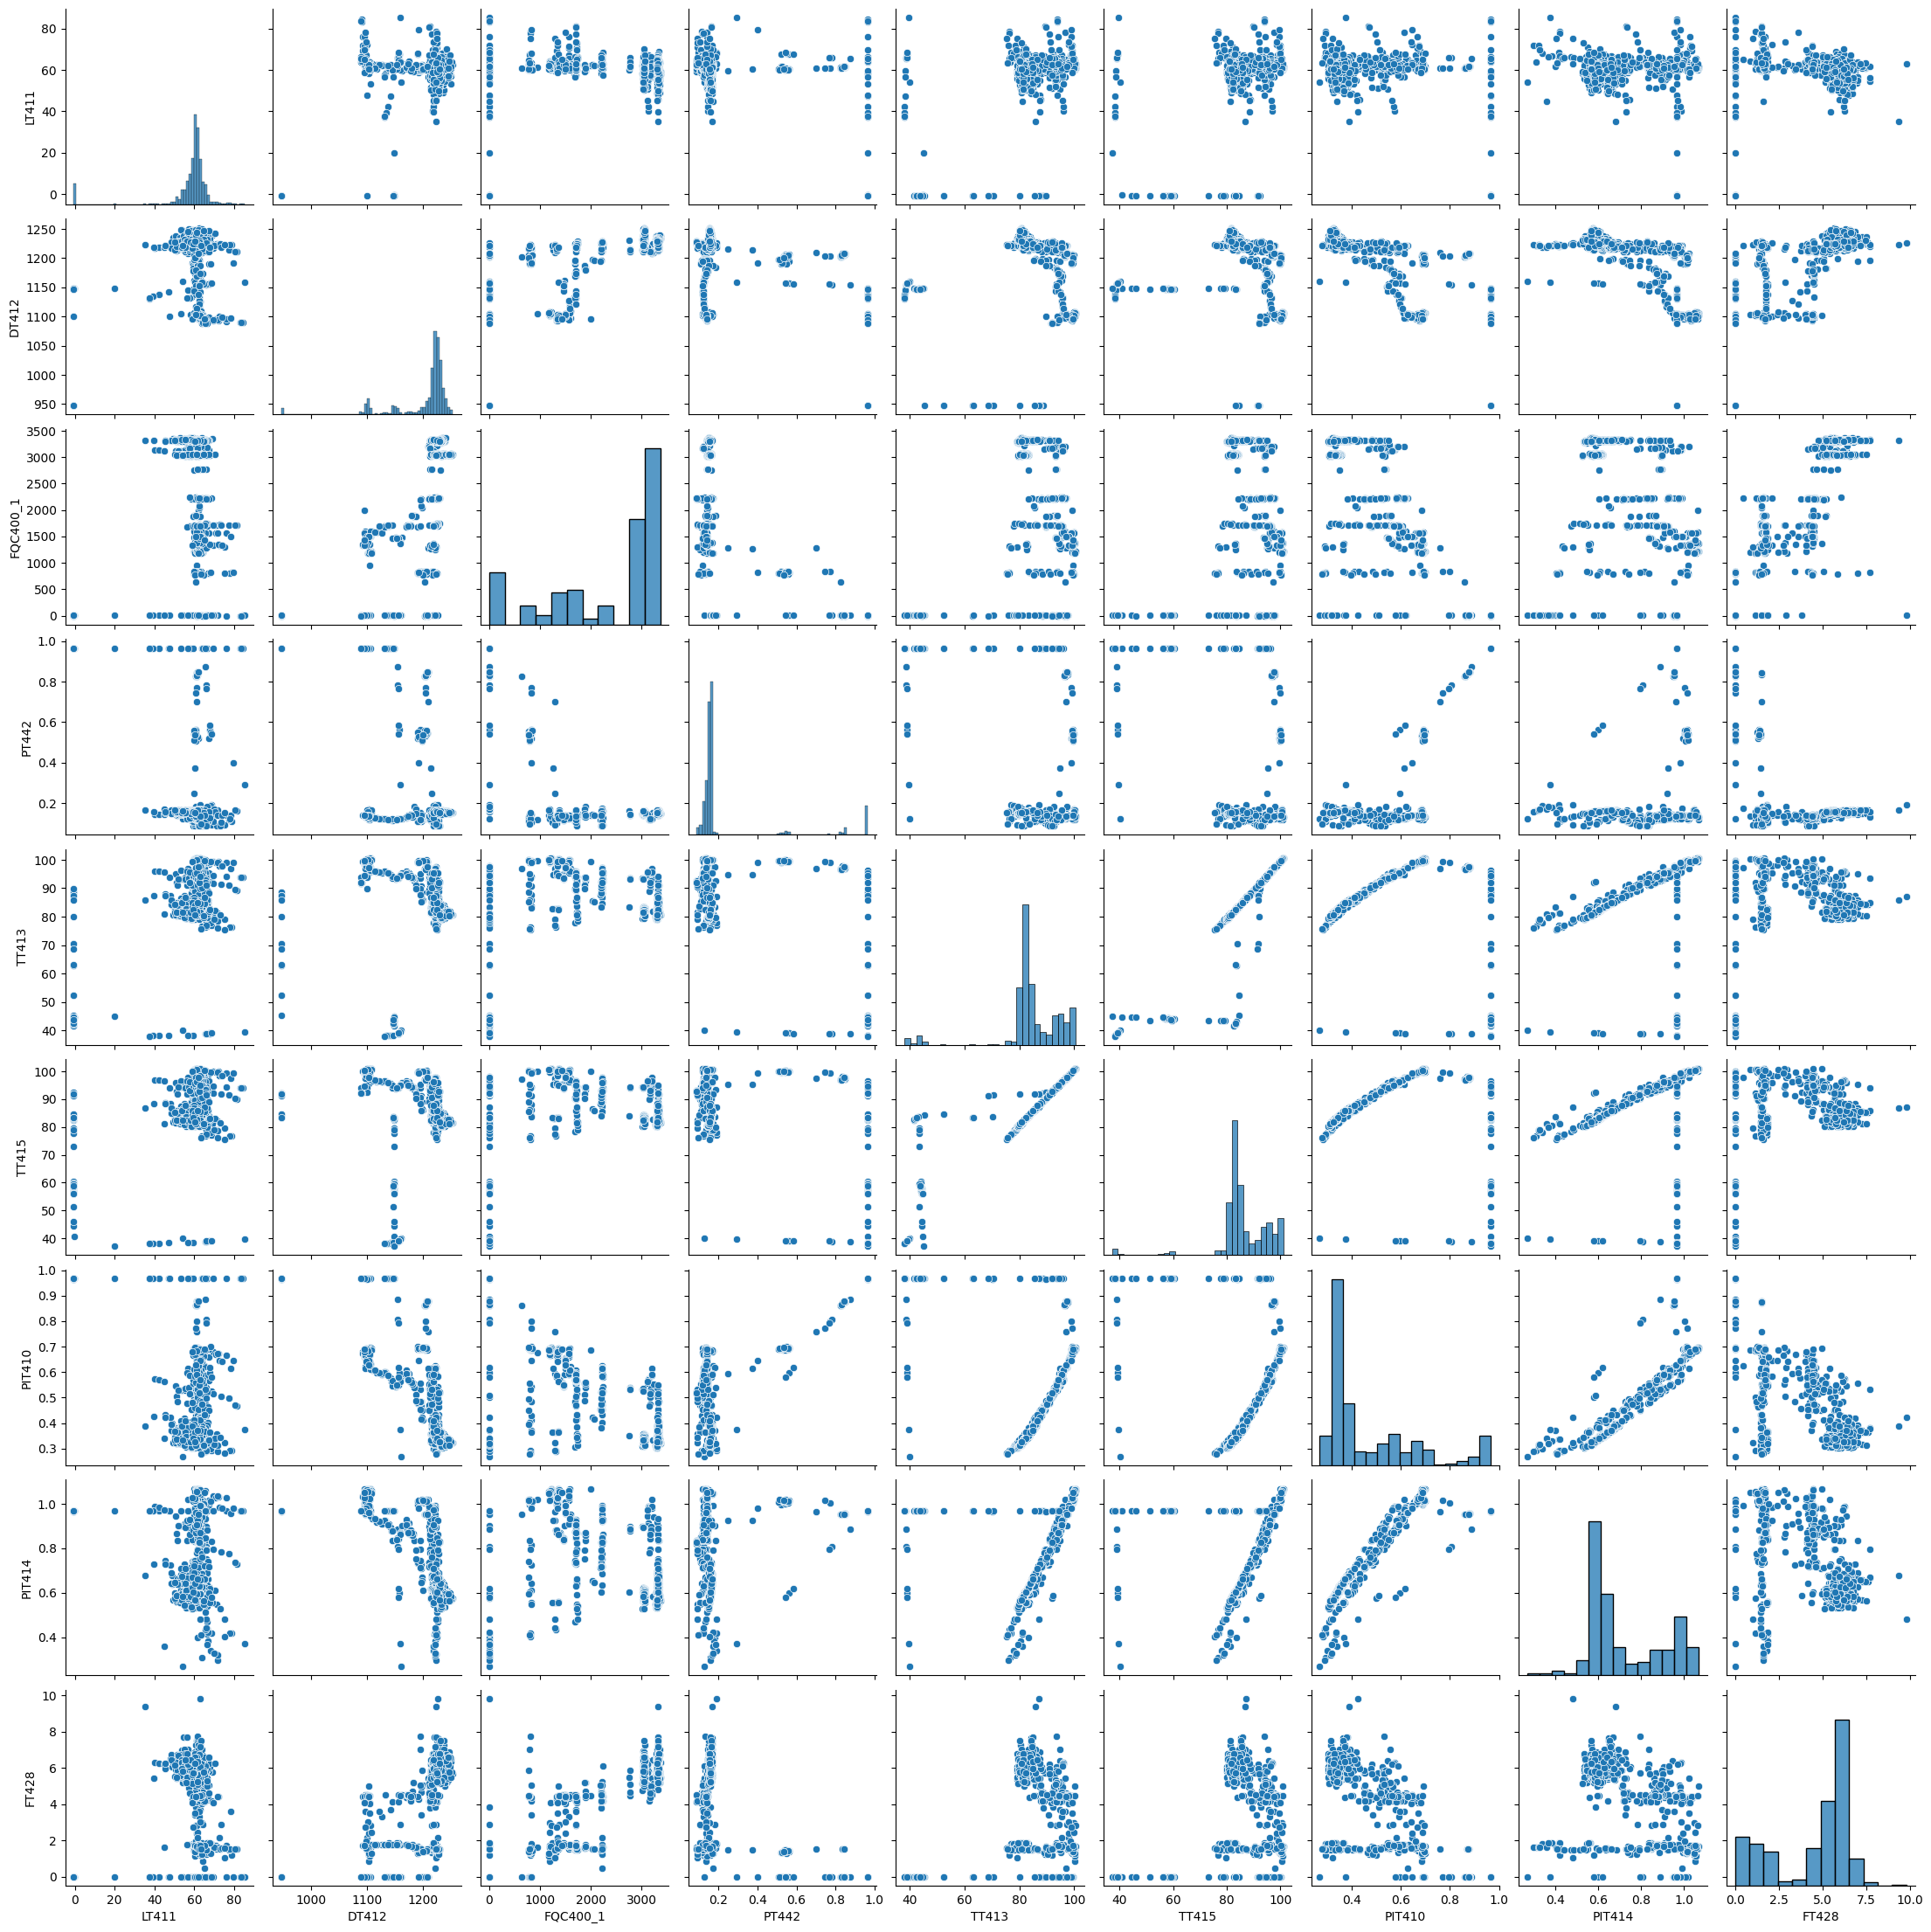

In [22]:
# Pairplot reducido de variables principales

variables_pairplot = [
    "LT411",
    "DT412",
    "FQC400_1",
    "PT442",
    "TT413",
    "TT415",
    "PIT410",
    "PIT414",
    "FT428"
]

df_pairplot = dataset_modelable[variables_pairplot].sample(1000, random_state=42)

sns.pairplot(df_pairplot)

plt.show()

## Conclusiones de limpieza

En este notebook se han unificado los 7 CSV válidos del proyecto mediante la columna temporal `Time`.

Se ha generado un dataset maestro a frecuencia original de 1 segundo:

- `data_limpio/dataset_unificado_1s.csv`

También se ha creado un dataset modelable remuestreado a 10 segundos:

- `data_limpio/dataset_modelable_10s.csv`

La frecuencia de 10 segundos se selecciona porque conserva bien la dinámica de LT411 y reduce el volumen de datos respecto a la señal original de 1 segundo.


El siguiente paso será construir las variables del Modelo A limpio, evitando `LV411`, `SP_LT411` y cualquier derivada de `LT411` como entrada del modelo.